# Problem Statement: Iterative Twitter/X Post Generator

Build a LangGraph workflow where the user provides a topic and the system generates a Twitter/X post.

The workflow should:

1. Use **LLM 1** to generate the initial post.
2. Use **LLM 2** to evaluate the post and provide a quality score + feedback.
3. If the score is above the required threshold, **end the workflow**.
4. If the score is below the threshold, use **LLM 3** to improve the post using the evaluator's feedback.
5. Send the improved post back to the evaluator and repeat the process.
6. Stop after a **maximum number of iterations** to prevent an infinite loop.

### Goal

Practice **conditional routing and looping in LangGraph**.

```text
Generate → Evaluate → Quality Check
               ↑           ↓
               └── Improve ←
               
Quality OK → END

In [151]:
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

from typing import TypedDict, Literal
from pydantic import BaseModel

from dotenv import load_dotenv
import os

In [84]:
load_dotenv()

True

In [85]:
# define LLMs

post_generator_llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0
)

evaluator_llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash-lite",
    temperature=0
)

improvizer_llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash-lite",
    temperature=0
) 

In [110]:
# define state schema
class PostGeneratorWorkflowState(TypedDict):
    topic: str
    post: str
    feedback: str
    rating: float
    result: Literal["approved", "needs_improvement"]

    iterations: int
    max_iterations: int 

In [111]:
# schema for llm 
class GeneratePostResponseSchema(BaseModel):
    post: str

class EvaluatorResponseSchema(BaseModel):
    evaluatation_result: Literal["approved", "needs_improvement"]
    feedback: str
    rating: int

class ImprovizerResponseSchema(BaseModel):
    post: str

In [112]:


def generate_post(state: PostGeneratorWorkflowState):

    post_generator_prompt = """
        You are a creative Twitter/X post writer.

        The user will provide a topic. Generate a funny, engaging, and concise Twitter/X post about that topic.

        Requirements:
        - Stay relevant to the given topic.
        - Make the post humorous and relatable.
        - Keep it concise and easy to read.
        - Make it suitable for a general social-media audience.
        - Do not invent unrelated facts.
        - Do not include explanations outside the post.

        Topic:
        {topic}
    """

    prompt = PromptTemplate(
        template = post_generator_prompt,
        input_variables=["topic"]
    )

    structure_llm = post_generator_llm.with_structured_output(GeneratePostResponseSchema)

    agent = prompt | structure_llm

    response = agent.invoke({"topic": state["topic"]})

    return {"post": response.post}



In [138]:


def evaluate_post(state: PostGeneratorWorkflowState):

   evaluator_prompt = """
You are a very strict quality evaluator for Twitter/X posts.

Evaluate the post based on:

- Relevance to the topic
- Appropriate tone for the topic
- Humor and entertainment value
- Strength of the opening hook
- Engagement potential
- Clarity and readability
- Originality
- Grammar and writing quality
- Conciseness

Give the post an overall rating from 1 to 10.

Rating guidelines:
- 1-3: Very poor quality, major improvements required
- 4-5: Below average, several improvements required
- 6-7: Decent but still needs improvement
- 8-9: High quality and suitable for publishing
- 10: Excellent, highly engaging and polished

Important rules:

- If the post contains MORE THAN 200 words, the rating must be 5 or below.
- If the topic is serious, sensitive, professional, or adult in nature, the post
  should use an appropriate tone.
- Do NOT force humor into a serious or sensitive topic.
- If the post uses inappropriate, childish, or insensitive humor for the topic,
  reduce the rating.
- If the topic is suitable for humor, reward clever and relevant humor.
- A serious topic can still receive a high rating if it is well-written and
  uses an appropriate tone.
- Approve the post ONLY if the rating is 8 or higher.
- If the rating is below 8, mark it as "needs_improvement".
- When the post needs improvement, provide specific and actionable feedback.

Topic:
{topic}

Post:
{post}
"""
   prompt = PromptTemplate(
      template = evaluator_prompt,
      input_variables=["topic", "post"]
   )

   structure_llm = evaluator_llm.with_structured_output(EvaluatorResponseSchema)

   agent = prompt | structure_llm

   response = agent.invoke({"topic": state["topic"], "post": state["post"]})

   return {"feedback": response.feedback, "result": response.evaluatation_result, "iterations": state["iterations"] + 1, "rating": response.rating}



In [139]:


def improve_post(state: PostGeneratorWorkflowState):

    improvizer_prompt = """
You are an expert Twitter/X post editor.

Improve the given post based on the evaluator's feedback.

Requirements:
- Preserve the original topic and core idea.
- Address every important issue mentioned in the feedback.
- Make the post funnier, clearer, and more engaging.
- Keep it concise and suitable for Twitter/X.
- Do not add unrelated information.
- Return only the improved post content.
- Ensure the improved post is no more than 200 words.

Topic:
{topic}

Current Post:
{post}

Evaluator Feedback:
{feedback}
"""

    prompt = PromptTemplate(
        template = improvizer_prompt,
        input_variables=["topic", "post", "feedback"]
    )

    structure_llm = improvizer_llm.with_structured_output(ImprovizerResponseSchema)

    agent = prompt | structure_llm

    response = agent.invoke({"topic": state["topic"], "post": state["post"], "feedback": state["feedback"]})

    return {"post": response.post}



In [142]:
def conditional_evaluation_router(state: PostGeneratorWorkflowState):
    if (state["result"] == 'approved' and state["rating"] > 8.5) or state["iterations"] >= state["max_iterations"]:
        return "approved"
    else:
        return "needs_improvement"

In [143]:
# initialized graph

graph = StateGraph(PostGeneratorWorkflowState)

graph.add_node("generate_post", generate_post)
graph.add_node("evaluate_post", evaluate_post)
graph.add_node("improve_post", improve_post)



In [144]:
graph.add_edge(START, "generate_post")
graph.add_edge("generate_post", "evaluate_post")
graph.add_conditional_edges("evaluate_post", conditional_evaluation_router, { "approved": END, "needs_improvement": "improve_post"})
graph.add_edge("improve_post", "evaluate_post")

In [145]:
workflow = graph.compile()

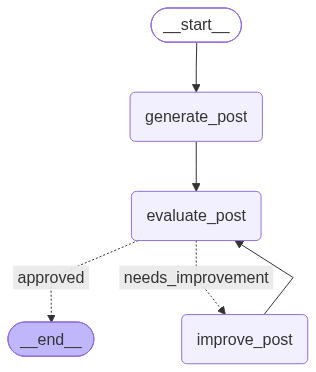

In [146]:
workflow

In [152]:
initial_state = {
    "topic": "i like dogs",
    "iterations": 0,
    "max_iterations": 4
}

result = workflow.invoke(initial_state)

/home/bhavin/workspace/langgraph-practice/.venv/lib/python3.14/site-packages/langchain_google_genai/chat_models.py:3120: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [153]:
result

{'topic': 'i like dogs',
 'post': "My personality type is just 'person who stops walking to pet a dog.' If you see me staring at your golden retriever, mind your business, I’m busy making a new best friend.",
 'feedback': "The post is highly relatable, concise, and has a strong hook that captures the reader's attention immediately. The humor is natural and fits the lighthearted topic perfectly. Grammar and readability are excellent.",
 'rating': 9,
 'result': 'approved',
 'iterations': 1,
 'max_iterations': 4}